In [1]:
import numpy as np
import matplotlib.pyplot as plt
import lemonpy as lp
from astropy import units as u

import pickle as pk

In [2]:
mu = 2.353
T0 = 30*u.K/mu
v0 = np.sqrt(lp.pluto_units.Rgas*T0)
R0 = lp.pluto_units.au
rho0 = 1e-12 * u.g/u.cm**3
units = lp.reader.get_units(velocity=v0, length=R0, density=rho0)

In [3]:
t0 = units['time'].to_value('yr')

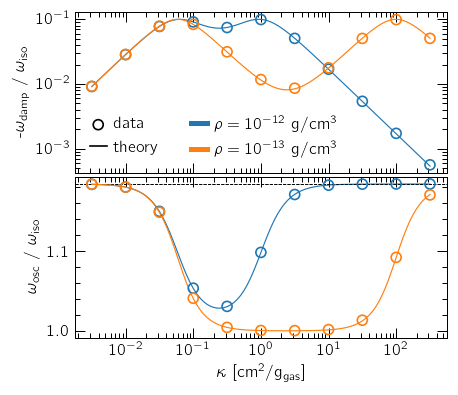

In [47]:
fig, ax = lp.plot.subplots(rows=2, dpi=120, hspace=0.02, rowsize=1.8)

fiso = 2*np.pi
f_time = 2*np.pi

for idx, dirc in enumerate(['rho1e-12', 'rho1e-13']):
    c = f'C{idx}'
    with open(f'petsc-data_{dirc}.pk', 'rb') as f: data = pk.load(f)
    
    ax[1].axhline(np.sqrt(1.4), ls='--', c='k', lw=0.5)

    ax[0].scatter(data['kappa'], data['eigenreal']/fiso, edgecolors=c, facecolors='none', marker='o', zorder=100)
    ax[0].plot(data['kappa_exp'], data['eigenreal_exp']/fiso, '-', c=c, lw=0.7)
    ax[1].scatter(data['kappa'], data['eigenimag']/fiso, edgecolors=c, facecolors='none', marker='o', zorder=100)
    ax[1].plot(data['kappa_exp'], data['eigenimag_exp']/fiso, '-', c=c, lw=0.7)

ax[0].scatter(np.nan, np.nan, label='data', marker='o', facecolors='none', edgecolors='k')
ax[0].plot(np.nan, np.nan, '-', c='k', label='theory')
ax[0].plot(np.nan, np.nan, c='C0', label=r'$\rho=10^{-12}$ g/cm${}^3$')
ax[0].plot(np.nan, np.nan, c='C1', label=r'$\rho=10^{-13}$ g/cm${}^3$')

ax[0].set_ylabel(r'-$\omega_\text{damp}$ / $\omega_\text{iso}$')
ax[1].set_ylabel(r'$\omega_\text{osc}$ / $\omega_\text{iso}$')

lg = ax[0].legend(ncol=2, handlelength=1, handletextpad=0.4)
for line in lg.get_lines()[1:]:
    line.set_lw(3)

ax[0].set_yscale('log')

ax[1].set_xlabel(r'$\kappa$ [cm${}^2$/g${}_\text{gas}$]')
for axis in ax: axis.set_xscale('log')
ax[0].set_xticklabels([])

fig.savefig('../figures/dynamic.pdf', bbox_inches='tight')
plt.show()

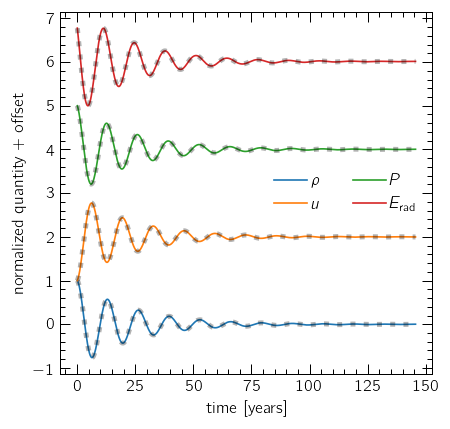

In [42]:
from scipy.optimize import curve_fit
def f(x, a, b, c, d, e): return a * np.sin(b*x+c) * np.exp(d*x) + e
def fit_eigenvalue(t, x, **kwargs): return curve_fit(f, t, x, **kwargs)[0]

with open('new-rho1e-12.pk', 'rb') as file: data = pk.load(file)
i = lp.tools.where(data['kappa'], 1)
t, rho, vx1, prs, Er = np.genfromtxt('data/rho1e-12/setups/kappa0.0/out/data_at_0.out', unpack=True)

fig, ax = lp.plot.subplots(dpi=120, rowsize=4)

def process(qty, idx):
    qty = qty / qty.mean() - 1
    qty /= np.abs(qty).max()
    qty += 2*idx
    return qty

labels = [r'$\rho$', '$u$', '$P$', '$E_\mathrm{rad}$']
for idx, q in enumerate([rho, vx1, prs, Er]):
    c    = f'C{idx}'
    j = lp.tools.where(t, 0.01)
    tfit, datafit = t[j:], q[j:]
    popt = fit_eigenvalue(tfit, datafit, p0=[0, 7, np.pi/2, -0.5, 0])
    mag, imag, phase, real, off = popt

    qty = process(datafit, idx)
    ax.plot(tfit*t0, qty, c=c, label=labels[idx])
    popt[1], popt[3] = data['eigenimag_exp'][i], -data['eigenreal_exp'][i]
    qty = process(f(tfit, *popt), idx)
    ax.plot(tfit*t0, qty, alpha=0.3, lw=3, c='k', ls=':')
    
ax.legend(ncol=2)
ax.set_ylabel(r'normalized quantity $+$ offset')
ax.set_xlabel(r'time [years]')
fig.savefig('../figures/dynamic-osc.pdf', bbox_inches='tight')
plt.show()